<a href="https://colab.research.google.com/github/mkromah/gbm-multisource-biomarker-project/blob/main/Note_Book%2008_shap_interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Imports and project paths
# ============================================================

import os
import numpy as np
import pandas as pd

PROJECT_NAME = "Glioma_ML_Biomarker_Project"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"

RESULTS_DIR = f"{BASE_DIR}/results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"

XENA_DIR = f"{RAW_DIR}/XENA"

print("Project root loaded:")
print(BASE_DIR)

Project root loaded:
/content/drive/MyDrive/Glioma_ML_Biomarker_Project


In [ ]:
# ============================================================
# Step 2: Load final biomarker panel
# ============================================================

final_biomarker_path = f"{RESULTS_DIR}/final_cross_cohort_biomarkers.csv"

final_biomarkers = pd.read_csv(final_biomarker_path)

print("Final biomarker panel loaded.")
print("Shape:", final_biomarkers.shape)

print("\nGenes:")
print(final_biomarkers["gene"].tolist())

Final biomarker panel loaded.
Shape: (21, 2)

Genes:
['MMP9', 'LINC00152', 'ESM1', 'CLIC1', 'SERPINH1', 'AGAP2-AS1', 'KCNB1', 'ANXA2', 'LOX', 'CCDC109B', 'EMP3', 'PLEK2', 'SH2D4A', 'TUBA1C', 'FN1', 'TNFRSF12A', 'RAB34', 'CA9', 'TAGLN2', 'GDF15', 'SPAG4']


In [ ]:
# ============================================================
# Step 3: Load phenotype metadata
# ============================================================

pheno_path = f"{XENA_DIR}/TcgaTargetGTEX_phenotype.txt.gz"

pheno = pd.read_csv(
    pheno_path,
    sep="\t",
    compression="gzip",
    encoding="latin1"
)

print("Phenotype table loaded.")
print("Shape:", pheno.shape)

pheno.head()

Phenotype table loaded.
Shape: (19131, 7)


,sample,detailed_category,primary disease or tissue,_primary_site,_sample_type,_gender,_study
0,TCGA-V4-A9EE-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
1,TCGA-VD-AA8N-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
2,TCGA-V4-A9EI-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
3,TCGA-VD-AA8O-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
4,TCGA-WC-A888-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA


In [ ]:
# ============================================================
# Step 4: Extract glioma samples
# ============================================================

glioma_samples = pheno[
    pheno["detailed_category"].isin([
        "Brain Lower Grade Glioma",
        "Glioblastoma Multiforme"
    ])
].copy()

glioma_samples = glioma_samples[
    glioma_samples["_sample_type"] == "Primary Tumor"
].copy()

print("TCGA glioma samples extracted.")
print("Shape:", glioma_samples.shape)

print("\nLabel distribution:")
print(glioma_samples["detailed_category"].value_counts())

TCGA glioma samples extracted.
Shape: (662, 7)

Label distribution:
detailed_category
Brain Lower Grade Glioma    509
Glioblastoma Multiforme     153
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 5: Load gene expression matrix
# ============================================================

expr_path = f"{XENA_DIR}/TcgaTargetGtex_rsem_gene_tpm.gz"

expr = pd.read_csv(
    expr_path,
    sep="\t",
    compression="gzip"
)

print("Expression matrix loaded.")
print("Shape:", expr.shape)

expr.head()

Expression matrix loaded.
Shape: (60498, 19132)


,sample,GTEX-S4Q7-0003-SM-3NM8M,TCGA-19-1787-01,TCGA-S9-A7J2-01,GTEX-QV31-1626-SM-2S1QC,TCGA-G3-A3CH-11,TCGA-B5-A5OE-01,GTEX-13QIC-0011-R1a-SM-5O9CJ,TCGA-B2-5641-11,GTEX-ZPCL-0126-SM-4WWC8,...,TCGA-FI-A2EY-01,TCGA-55-6985-11,TCGA-EJ-5527-01,TCGA-G3-A25X-01,TCGA-24-2254-01,GTEX-11ZTS-3326-SM-5LU9Y,GTEX-VJYA-0726-SM-4KL1T,GTEX-ZA64-2126-SM-5Q5A8,GTEX-Q2AG-2826-SM-2HMJQ,GTEX-XV7Q-0426-SM-4BRVN
0,ENSG00000242268.2,-3.4580,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-4.0350,-2.0529,-9.9658,-9.9658,-1.9379,1.5165,-9.9658,-2.3884,0.0440,-3.3076
1,ENSG00000259041.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658
2,ENSG00000270112.3,-3.6259,-3.8160,-3.0469,-2.1779,-9.9658,-9.9658,-1.8314,-2.4659,-9.9658,...,-3.1714,-4.2934,-9.9658,-9.9658,-5.5735,-2.9324,-9.9658,-9.9658,2.5852,-3.0469
3,ENSG00000167578.16,4.5988,5.2998,4.8881,4.6294,3.5572,5.0858,6.4989,4.6317,5.5358,...,4.7253,5.4206,4.4771,5.2627,5.0760,6.0809,4.7410,5.3212,5.8110,5.9132
4,ENSG00000278814.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658


In [ ]:
# ============================================================
# Step 6: Load gene annotation map
# ============================================================

probe_path = f"{XENA_DIR}/probeMap_gencode.v23.annotation.gene.probemap"

probe_map = pd.read_csv(probe_path, sep="\t")

print("Gene annotation map loaded.")
print("Shape:", probe_map.shape)

probe_map.head()

Gene annotation map loaded.
Shape: (60498, 6)


,id,gene,chrom,chromStart,chromEnd,strand
0,ENSG00000223972.5,DDX11L1,chr1,11869,14409,+
1,ENSG00000227232.5,WASH7P,chr1,14404,29570,-
2,ENSG00000278267.1,MIR6859-1,chr1,17369,17436,-
3,ENSG00000243485.3,RP11-34P13.3,chr1,29554,31109,+
4,ENSG00000274890.1,MIR1302-2,chr1,30366,30503,+


In [ ]:
# ============================================================
# Step 7: Map Ensembl IDs and extract biomarker genes
# ============================================================

# Clean Ensembl IDs
expr = expr.copy()
expr["ensembl_id"] = expr["sample"].astype(str).str.split(".").str[0]

probe_map = probe_map.copy()
probe_map["ensembl_id"] = probe_map["id"].astype(str).str.split(".").str[0]

# Merge expression with annotation
expr_annot = expr.merge(
    probe_map[["ensembl_id", "gene"]],
    on="ensembl_id",
    how="left"
)

# Keep only final biomarker genes
biomarker_genes = final_biomarkers["gene"].dropna().unique().tolist()

expr_biomarkers = expr_annot[
    expr_annot["gene"].isin(biomarker_genes)
].copy()

print("Biomarker expression matrix extracted.")
print("Shape:", expr_biomarkers.shape)

print("\nExtracted genes:")
print(sorted(expr_biomarkers["gene"].dropna().unique().tolist()))

Biomarker expression matrix extracted.
Shape: (21, 19134)

Extracted genes:
['AGAP2-AS1', 'ANXA2', 'CA9', 'CCDC109B', 'CLIC1', 'EMP3', 'ESM1', 'FN1', 'GDF15', 'KCNB1', 'LINC00152', 'LOX', 'MMP9', 'PLEK2', 'RAB34', 'SERPINH1', 'SH2D4A', 'SPAG4', 'TAGLN2', 'TNFRSF12A', 'TUBA1C']


In [ ]:
# ============================================================
# Step 8: Build TCGA biomarker matrix
# ============================================================

# Set gene names as index
expr_biomarkers = expr_biomarkers.set_index("gene")

# Drop annotation columns
expr_biomarkers = expr_biomarkers.drop(columns=["sample", "ensembl_id"], errors="ignore")

# Transpose to samples × genes
tcga_matrix = expr_biomarkers.T

# Keep only glioma samples
glioma_sample_ids = glioma_samples["sample"].tolist()
tcga_glioma_matrix = tcga_matrix.loc[tcga_matrix.index.intersection(glioma_sample_ids)].copy()

print("TCGA glioma biomarker matrix created.")
print("Shape:", tcga_glioma_matrix.shape)

tcga_glioma_matrix.head()

TCGA glioma biomarker matrix created.
Shape: (662, 21)


gene,ESM1,TUBA1C,SPAG4,KCNB1,PLEK2,FN1,ANXA2,CA9,AGAP2-AS1,CLIC1,...,CCDC109B,LOX,SERPINH1,SH2D4A,LINC00152,TNFRSF12A,RAB34,TAGLN2,MMP9,EMP3
TCGA-19-1787-01,1.0779,8.8210,0.8488,2.2144,1.4335,8.1679,9.3479,2.2299,3.4061,8.1538,...,5.2634,3.0234,6.6521,2.9525,3.9108,6.8545,6.2968,9.0363,5.6453,8.4528
TCGA-S9-A7J2-01,-1.2828,4.3807,-0.9971,3.1011,-2.1140,6.0943,3.5706,-0.1504,0.4657,4.2404,...,1.0847,-1.3921,4.5922,-3.4580,0.3346,1.8762,2.3981,5.4270,-1.5951,0.5763
TCGA-E1-A7YI-01,-3.3076,4.3938,0.5370,2.3106,-0.9686,7.4119,6.5097,-1.3548,0.4761,7.2855,...,2.1147,0.5170,5.4142,-1.0262,6.1281,8.0595,2.9929,9.0730,-1.9379,7.5023
TCGA-06-5412-01,3.3966,8.6443,3.0020,-1.3548,2.9071,9.7850,9.1379,4.7682,2.9469,9.0624,...,5.0396,5.5528,7.0677,2.3508,6.7071,7.5053,6.8825,8.7659,5.2758,7.7923
TCGA-DU-7302-01,-3.8160,3.6054,-1.8314,4.4588,-0.9686,5.5766,4.6047,-1.0559,-0.4719,4.3278,...,1.8840,-0.8599,3.3633,-1.5951,3.6691,2.1606,3.6669,5.4460,-1.7809,2.9224


In [ ]:
# ============================================================
# Step 9: Create labels and train Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create binary labels
label_map = glioma_samples.set_index("sample")["detailed_category"].map({
    "Brain Lower Grade Glioma": 0,
    "Glioblastoma Multiforme": 1
})

y_tcga = tcga_glioma_matrix.index.to_series().map(label_map)
X_tcga = tcga_glioma_matrix.copy()

print("Feature matrix shape:", X_tcga.shape)
print("Label vector shape:", y_tcga.shape)

print("\nLabel distribution:")
print(y_tcga.value_counts())

# Train Random Forest on full TCGA cohort
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_tcga, y_tcga)

print("\nRandom Forest model trained successfully.")

Feature matrix shape: (662, 21)
Label vector shape: (662,)

Label distribution:
0    509
1    153
Name: count, dtype: int64

Random Forest model trained successfully.


In [ ]:
# ============================================================
# Step 10: Install and import SHAP
# ============================================================

!pip install shap

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [ ]:
# ============================================================
# Step 11: Compute SHAP values
# ============================================================

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_tcga)

print("SHAP values computed.")

print("Shape of SHAP values:")
print(len(shap_values), shap_values[1].shape)

SHAP values computed.
Shape of SHAP values:
662 (21, 2)


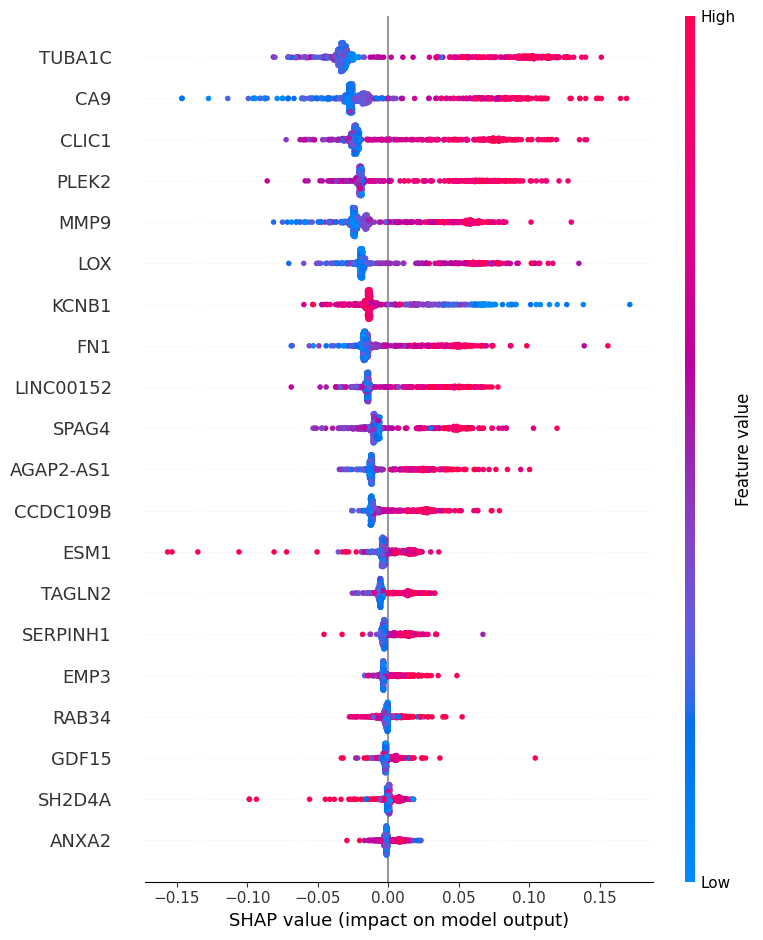

SHAP summary plot saved.


In [ ]:
# ============================================================
# Step 12: SHAP summary plot
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Extract SHAP values for the GBM class
shap_vals_gbm = shap_values[:, :, 1]

plt.figure()

shap.summary_plot(
    shap_vals_gbm,
    X_tcga,
    plot_type="dot",
    show=False
)

plt.savefig(
    f"{FIGURES_DIR}/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP summary plot saved.")

In [ ]:
# ============================================================
# Step 13: Calculate mean SHAP importance
# ============================================================

import pandas as pd
import numpy as np

# mean absolute SHAP importance
importance = np.abs(shap_vals_gbm).mean(axis=0)

importance_df = pd.DataFrame({
    "Gene": X_tcga.columns,
    "Mean_SHAP_Importance": importance
})

importance_df = importance_df.sort_values(
    by="Mean_SHAP_Importance",
    ascending=False
)

importance_df.head(15)

,Gene,Mean_SHAP_Importance
1,TUBA1C,0.049171
7,CA9,0.039376
9,CLIC1,0.035328
4,PLEK2,0.030966
19,MMP9,0.030534
12,LOX,0.030389
3,KCNB1,0.023900
5,FN1,0.022971
15,LINC00152,0.022265
2,SPAG4,0.018828


In [ ]:
importance_df.to_csv(
    f"{RESULTS_DIR}/gene_shap_importance_ranking.csv",
    index=False
)

print("Gene importance table saved.")

Gene importance table saved.
